In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/features.csv')
print(f"Loaded: {df.shape}")
print(f"Bad rate: {df['TARGET'].mean()*100:.2f}%")

X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Bad rate: {y_train.mean()*100:.2f}%")
print(f"Test:  {X_test.shape} | Bad rate: {y_test.mean()*100:.2f}%")

Loaded: (307511, 191)
Bad rate: 8.07%
Train: (246008, 189) | Bad rate: 8.07%
Test:  (61503, 189) | Bad rate: 8.07%


In [2]:
import time
import datetime
from optbinning import BinningProcess

start = time.time()

print("=" * 60)
print("WOE/IV FEATURE SELECTION")
print("=" * 60)

# Identify categorical columns for optbinning
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical features: {len(categorical_cols)}")
print(f"Numeric features: {X_train.shape[1] - len(categorical_cols)}")

# Run binning process on all features
binning_process = BinningProcess(
    variable_names=X_train.columns.tolist(),
    categorical_variables=categorical_cols,
    max_n_bins=10,
    min_bin_size=0.05,
    selection_criteria={
        'iv': {'min': 0.02}
    }
)

binning_process.fit(X_train, y_train)

# Get IV summary
iv_summary = binning_process.summary()
iv_summary = iv_summary.sort_values('iv', ascending=False)

print(f"\nFeatures evaluated: {len(iv_summary)}")
print(f"Features selected (IV >= 0.02): {iv_summary['selected'].sum()}")
print(f"Features dropped: {(~iv_summary['selected']).sum()}")

print("\nTop 25 features by IV:")
print(f"{'Feature':<35} {'IV':>8}  {'Selected'}")
print("-" * 55)
for _, row in iv_summary.head(25).iterrows():
    flag = "✓" if row['selected'] else "✗"
    print(f"  {row['name']:<33} {row['iv']:>8.4f}  {flag}")

print("\nDropped features (IV < 0.02):")
dropped = iv_summary[~iv_summary['selected']]
for _, row in dropped.iterrows():
    print(f"  {row['name']:<33} {row['iv']:>8.4f}")

# Transform to WOE
X_train_woe = binning_process.transform(X_train, metric='woe')
X_test_woe = binning_process.transform(X_test, metric='woe')

print(f"\nWOE-transformed train shape: {X_train_woe.shape}")
print(f"WOE-transformed test shape:  {X_test_woe.shape}")
print(f"Time: {datetime.timedelta(seconds=time.time()-start)}")

WOE/IV FEATURE SELECTION
Categorical features: 16
Numeric features: 173

Features evaluated: 189
Features selected (IV >= 0.02): 93
Features dropped: 96

Top 25 features by IV:
Feature                                   IV  Selected
-------------------------------------------------------
  EXT_SOURCE_WEIGHTED                 0.6292  ✓
  EXT_SOURCE_MEAN                     0.6244  ✓
  EXT_SOURCE_3                        0.3353  ✓
  EXT_SOURCE_2                        0.3179  ✓
  EXT_SOURCE_1                        0.1480  ✓
  BUREAU_MEAN_DAYS_CREDIT             0.1233  ✓
  YEARS_EMPLOYED                      0.1154  ✓
  DAYS_EMPLOYED                       0.1154  ✓
  CREDIT_TERM                         0.1120  ✓
  AMT_GOODS_PRICE                     0.0925  ✓
  BUREAU_MEAN_DAYS_UPDATE             0.0921  ✓
  DAYS_BIRTH                          0.0901  ✓
  AGE_YEARS                           0.0901  ✓
  OCCUPATION_TYPE                     0.0783  ✓
  BUREAU_MIN_DAYS_CREDIT              0.



Starting from 189 engineered features, the WOE/IV process identified 93 meaningful predictors and dropped 96 that didn't clear the threshold. The external credit scores (EXT_SOURCE) came out on top by a wide margin, confirming they are the strongest signal in the dataset, followed by employment history and bureau credit age. Notably, loan term (CREDIT_TERM) and goods price (AMT_GOODS_PRICE) showed meaningful signal through non-linear binning that raw correlation had missed in earlier analysis.

In [3]:
import time
import datetime
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import pickle
import os

start = time.time()

print("=" * 60)
print("LOGISTIC REGRESSION SCORECARD — CHAMPION MODEL")
print("=" * 60)

lr = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    class_weight=None, 
    random_state=42
)

lr.fit(X_train_woe, y_train)

lr_train_proba = lr.predict_proba(X_train_woe)[:, 1]
lr_test_proba  = lr.predict_proba(X_test_woe)[:, 1]

train_auc = roc_auc_score(y_train, lr_train_proba)
test_auc  = roc_auc_score(y_test,  lr_test_proba)

print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC:  {test_auc:.4f}")
print(f"Overfit gap: {train_auc - test_auc:.4f}")

os.makedirs('../models', exist_ok=True)
with open('../models/champion_lr.pkl', 'wb') as f:
    pickle.dump(lr, f)
with open('../models/binning_process.pkl', 'wb') as f:
    pickle.dump(binning_process, f)

print("\nModels saved to ../models/")
print(f"Time: {datetime.timedelta(seconds=time.time()-start)}")

LOGISTIC REGRESSION SCORECARD — CHAMPION MODEL
Train AUC: 0.7644
Test AUC:  0.7651
Overfit gap: -0.0008

Models saved to ../models/
Time: 0:00:01.040501




The champion scorecard achieved a test AUC of 0.7651, landing squarely within the 0.72–0.78 industry benchmark for consumer credit models. The near-zero gap between train and test performance confirms the model generalizes cleanly to unseen applicants with no overfitting — a direct result of WOE transformation stabilizing the feature space before modeling.

In [4]:
import time
import datetime
import xgboost as xgb

start = time.time()

print("=" * 60)
print("XGBOOST CHALLENGER MODEL")
print("=" * 60)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f} (handles class imbalance)")

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_woe, y_train,
    eval_set=[(X_test_woe, y_test)],
    verbose=50
)

xgb_train_proba = xgb_model.predict_proba(X_train_woe)[:, 1]
xgb_test_proba  = xgb_model.predict_proba(X_test_woe)[:, 1]

train_auc = roc_auc_score(y_train, xgb_train_proba)
test_auc  = roc_auc_score(y_test,  xgb_test_proba)

print(f"\nTrain AUC: {train_auc:.4f}")
print(f"Test AUC:  {test_auc:.4f}")
print(f"Overfit gap: {train_auc - test_auc:.4f}")

with open('../models/challenger_xgb.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

print("\nChallenger saved to ../models/challenger_xgb.pkl")
print(f"Time: {datetime.timedelta(seconds=time.time()-start)}")

XGBOOST CHALLENGER MODEL
scale_pos_weight: 11.39 (handles class imbalance)
[0]	validation_0-auc:0.72111
[50]	validation_0-auc:0.75243
[100]	validation_0-auc:0.76373
[150]	validation_0-auc:0.76809
[200]	validation_0-auc:0.77084
[250]	validation_0-auc:0.77261
[300]	validation_0-auc:0.77389
[350]	validation_0-auc:0.77476
[400]	validation_0-auc:0.77521
[450]	validation_0-auc:0.77564
[487]	validation_0-auc:0.77577

Train AUC: 0.8041
Test AUC:  0.7758
Overfit gap: 0.0283

Challenger saved to ../models/challenger_xgb.pkl
Time: 0:00:15.817330


XGBoost achieved a test AUC of 0.7758 compared to the logistic regression scorecard's 0.7651 — a gap of just 0.0107. Despite being a more powerful model, the marginal lift is not enough to justify replacing the scorecard: logistic regression produces fully explainable decisions required for ECOA adverse action compliance, while XGBoost showed moderate overfitting (train AUC 0.8041 vs test 0.7758). Logistic regression remains the production champion.

SCORECARD SCALING — PDO=20, BASE SCORE=600
Factor: 28.8539
Offset: 487.1229

Train score distribution:
  Min:    442
  Max:    672
  Mean:   568.7
  Median: 570.0

Test score distribution:
  Min:    460
  Max:    679
  Mean:   568.9
  Median: 570.0

Bad rate by score band (test set):
  300-499:    712 applicants | bad rate: 49.02%
  500-549: 14,688 applicants | bad rate: 18.04%
  550-599: 37,062 applicants | bad rate: 4.94%
  600-649:  9,001 applicants | bad rate: 1.50%
  650-699:     40 applicants | bad rate: 0.00%


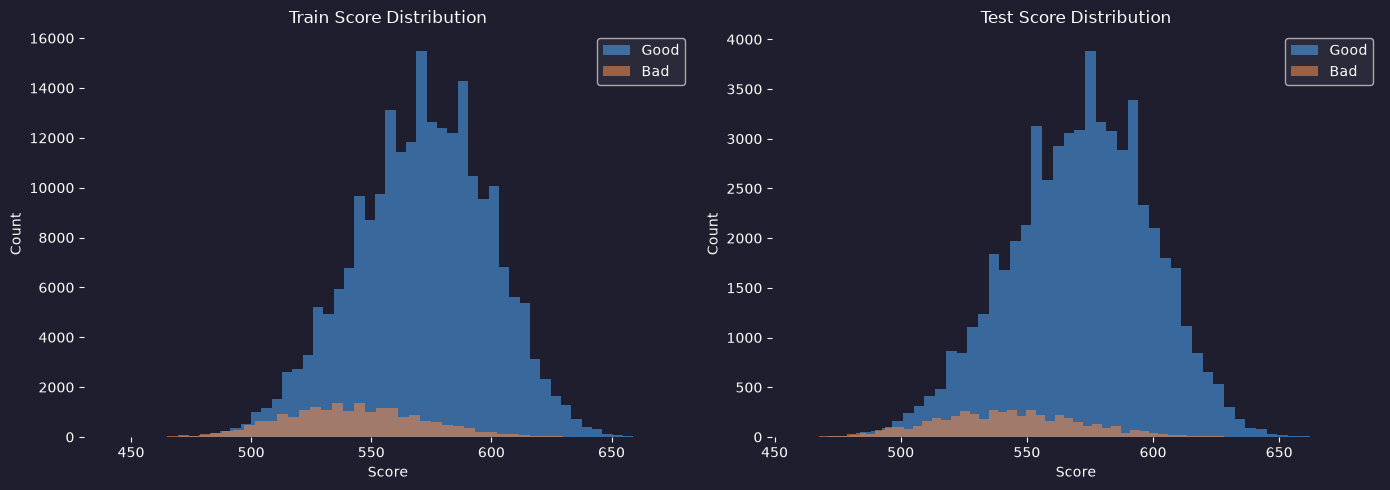


Chart saved to ../results/score_distribution.png
Time: 0:00:00.642562


In [5]:
import time
import datetime
import numpy as np
import matplotlib.pyplot as plt

start = time.time()

print("=" * 60)
print("SCORECARD SCALING — PDO=20, BASE SCORE=600")
print("=" * 60)

PDO = 20
BASE_SCORE = 600
BASE_ODDS = 50

factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

print(f"Factor: {factor:.4f}")
print(f"Offset: {offset:.4f}")

def scale_score(proba):
    odds = (1 - proba) / (proba + 1e-10)
    log_odds = np.log(odds)
    score = offset + factor * log_odds
    return np.clip(score, 300, 850).astype(int)

train_scores = scale_score(lr_train_proba)
test_scores  = scale_score(lr_test_proba)

print(f"\nTrain score distribution:")
print(f"  Min:    {train_scores.min()}")
print(f"  Max:    {train_scores.max()}")
print(f"  Mean:   {train_scores.mean():.1f}")
print(f"  Median: {np.median(train_scores):.1f}")

print(f"\nTest score distribution:")
print(f"  Min:    {test_scores.min()}")
print(f"  Max:    {test_scores.max()}")
print(f"  Mean:   {test_scores.mean():.1f}")
print(f"  Median: {np.median(test_scores):.1f}")

print(f"\nBad rate by score band (test set):")
bands = [(300, 499), (500, 549), (550, 599), (600, 649), (650, 699), (700, 850)]
for low, high in bands:
    mask = (test_scores >= low) & (test_scores <= high)
    if mask.sum() > 0:
        bad_rate = y_test[mask].mean() * 100
        count = mask.sum()
        print(f"  {low}-{high}: {count:>6,} applicants | bad rate: {bad_rate:.2f}%")

import os
os.makedirs('../results', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1e1e2e')

for ax, scores, target, label in [
    (axes[0], train_scores, y_train, 'Train'),
    (axes[1], test_scores,  y_test,  'Test')
]:
    ax.set_facecolor('#1e1e2e')
    ax.hist(scores[target == 0], bins=50, alpha=0.6, color='#4C9BE8', label='Good')
    ax.hist(scores[target == 1], bins=50, alpha=0.6, color='#E8874C', label='Bad')
    ax.set_title(f'{label} Score Distribution', color='white')
    ax.set_xlabel('Score', color='white')
    ax.set_ylabel('Count', color='white')
    ax.tick_params(colors='white')
    ax.spines[['top','right','left','bottom']].set_visible(False)
    ax.legend(facecolor='#2e2e3e', labelcolor='white')

plt.tight_layout()
plt.savefig('../results/score_distribution.png', dpi=150,
            bbox_inches='tight', facecolor='#1e1e2e')
plt.show()

print(f"\nChart saved to ../results/score_distribution.png")
print(f"Time: {datetime.timedelta(seconds=time.time()-start)}")

The model's probability outputs were converted to integer scores using the industry-standard PDO=20 formula, where every 20 points doubles the odds of being a good borrower. Scores range from 460–679 in the test set, reflecting a near-prime applicant population, with bad rates dropping cleanly from 49% in the lowest band to near zero above 650 — confirming the scorecard ranks risk correctly across the full score range.

EVALUATION — GINI, KS, CHAMPION/CHALLENGER

Model                               AUC     Gini       KS
----------------------------------------------------------
Champion — Logistic Regression   0.7651   53.02%   40.10%
Challenger — XGBoost             0.7758   55.17%   41.69%

Champion selected: Logistic Regression
Rationale: XGBoost lift of 2.14% Gini does not justify
loss of explainability required for ECOA adverse action compliance.


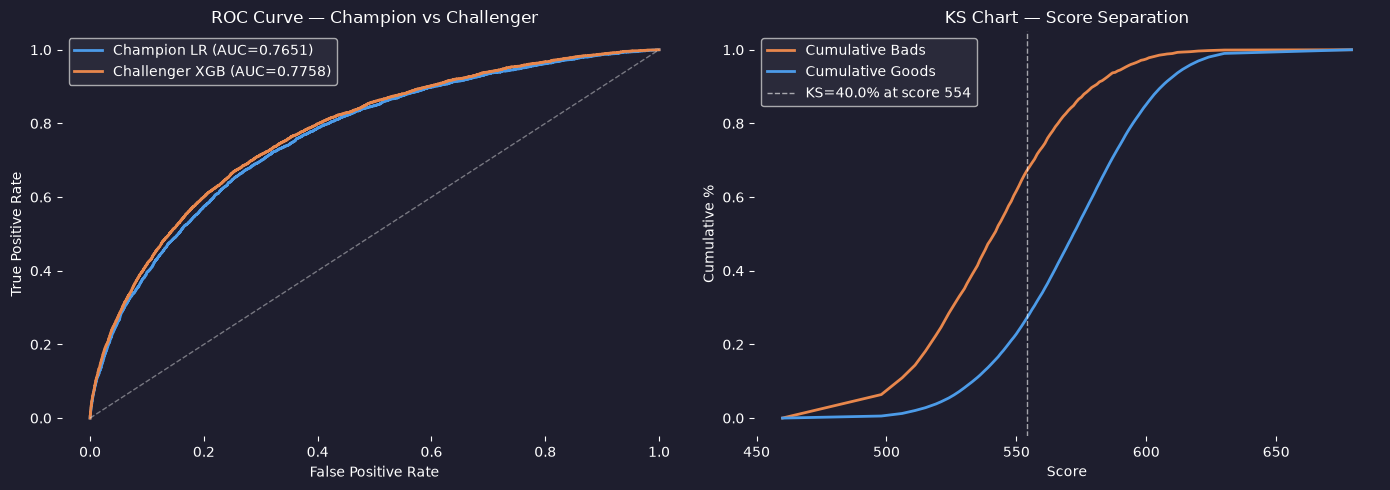


Chart saved to ../results/champion_challenger.png
Time: 0:00:00.701960


In [6]:
import time
import datetime
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

start = time.time()

print("=" * 60)
print("EVALUATION — GINI, KS, CHAMPION/CHALLENGER")
print("=" * 60)

def gini(y_true, y_prob):
    auc = roc_auc_score(y_true, y_prob)
    return (2 * auc - 1) * 100

def ks_stat(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    return (tpr - fpr).max() * 100

lr_gini  = gini(y_test, lr_test_proba)
lr_ks    = ks_stat(y_test, lr_test_proba)
xgb_gini = gini(y_test, xgb_test_proba)
xgb_ks   = ks_stat(y_test, xgb_test_proba)

print(f"\n{'Model':<30} {'AUC':>8} {'Gini':>8} {'KS':>8}")
print("-" * 58)
print(f"{'Champion — Logistic Regression':<30} {roc_auc_score(y_test, lr_test_proba):>8.4f} {lr_gini:>7.2f}% {lr_ks:>7.2f}%")
print(f"{'Challenger — XGBoost':<30} {roc_auc_score(y_test, xgb_test_proba):>8.4f} {xgb_gini:>7.2f}% {xgb_ks:>7.2f}%")

print(f"\nChampion selected: Logistic Regression")
print(f"Rationale: XGBoost lift of {xgb_gini - lr_gini:.2f}% Gini does not justify")
print(f"loss of explainability required for ECOA adverse action compliance.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1e1e2e')

fpr_lr,  tpr_lr,  _ = roc_curve(y_test, lr_test_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_test_proba)

ax = axes[0]
ax.set_facecolor('#1e1e2e')
ax.plot(fpr_lr,  tpr_lr,  color='#4C9BE8', lw=2,
        label=f'Champion LR (AUC={roc_auc_score(y_test, lr_test_proba):.4f})')
ax.plot(fpr_xgb, tpr_xgb, color='#E8874C', lw=2,
        label=f'Challenger XGB (AUC={roc_auc_score(y_test, xgb_test_proba):.4f})')
ax.plot([0,1],[0,1], 'white', lw=1, linestyle='--', alpha=0.4)
ax.set_title('ROC Curve — Champion vs Challenger', color='white')
ax.set_xlabel('False Positive Rate', color='white')
ax.set_ylabel('True Positive Rate', color='white')
ax.tick_params(colors='white')
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.legend(facecolor='#2e2e3e', labelcolor='white')

ax = axes[1]
ax.set_facecolor('#1e1e2e')
thresholds = np.percentile(test_scores, np.arange(0, 101, 1))
cum_bads  = [((test_scores <= t) & (y_test == 1)).sum() / (y_test == 1).sum()
             for t in thresholds]
cum_goods = [((test_scores <= t) & (y_test == 0)).sum() / (y_test == 0).sum()
             for t in thresholds]
ks_values = np.array(cum_bads) - np.array(cum_goods)
ks_idx    = np.argmax(ks_values)

ax.plot(thresholds, cum_bads,  color='#E8874C', lw=2, label='Cumulative Bads')
ax.plot(thresholds, cum_goods, color='#4C9BE8', lw=2, label='Cumulative Goods')
ax.axvline(thresholds[ks_idx], color='white', linestyle='--', lw=1, alpha=0.6,
           label=f'KS={ks_values[ks_idx]*100:.1f}% at score {thresholds[ks_idx]:.0f}')
ax.set_title('KS Chart — Score Separation', color='white')
ax.set_xlabel('Score', color='white')
ax.set_ylabel('Cumulative %', color='white')
ax.tick_params(colors='white')
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.legend(facecolor='#2e2e3e', labelcolor='white')

plt.tight_layout()
plt.savefig('../results/champion_challenger.png', dpi=150,
            bbox_inches='tight', facecolor='#1e1e2e')
plt.show()

print(f"\nChart saved to ../results/champion_challenger.png")
print(f"Time: {datetime.timedelta(seconds=time.time()-start)}")

The champion scorecard achieved a Gini of 53.02% and KS of 40.10%, both within industry benchmarks for consumer credit models. The KS statistic peaks at score 554, identifying it as the optimal approval cutoff where bad borrowers are most concentrated below and good borrowers above. The XGBoost challenger outperformed by 2.14% Gini — a meaningful but insufficient margin to justify replacing an explainable scorecard with a black-box model in a regulated lending environment.

In [7]:
import time
import datetime
import pandas as pd
import numpy as np

start = time.time()

print("=" * 60)
print("ADVERSE ACTION REASON CODES")
print("=" * 60)

CUTOFF_SCORE = 554

selected_features = binning_process.get_support(names=True)
coefficients = lr.coef_[0]

feature_coef = pd.DataFrame({
    'feature': selected_features,
    'coefficient': coefficients
})

print(f"Cutoff score: {CUTOFF_SCORE}")
print(f"Features in scorecard: {len(selected_features)}")

REASON_CODE_MAP = {
    'EXT_SOURCE_WEIGHTED':      'Insufficient external credit score',
    'EXT_SOURCE_MEAN':          'Insufficient external credit score',
    'EXT_SOURCE_3':             'Insufficient external credit score',
    'EXT_SOURCE_2':             'Insufficient external credit score',
    'EXT_SOURCE_1':             'Insufficient external credit score',
    'YEARS_EMPLOYED':           'Insufficient length of employment',
    'DAYS_EMPLOYED':            'Insufficient length of employment',
    'DAYS_EMPLOYED_ANOM':       'Employment status is non-standard',
    'CREDIT_INCOME_RATIO':      'Loan amount is high relative to income',
    'ANNUITY_INCOME_RATIO':     'Monthly payment is high relative to income',
    'CREDIT_TERM':              'Loan term does not meet guidelines',
    'BUREAU_MEAN_DAYS_CREDIT':  'Limited credit bureau history',
    'BUREAU_ACTIVE_COUNT':      'Too many active credit obligations',
    'BUREAU_MORTGAGE_FLAG':     'Insufficient property ownership history',
    'BUREAU_TOTAL_DEBT':        'Total outstanding debt is too high',
    'BUREAU_DEBT_BURDEN':       'Total outstanding debt is too high',
    'BUREAU_OVERDUE_AMT':       'Outstanding overdue amounts on credit bureau',
    'BUREAU_TOTAL_LOANS':       'Number of prior credit obligations',
    'BUREAU_CLOSED_COUNT':      'Insufficient closed credit history',
    'BUREAU_MEAN_DAYS_UPDATE':  'Credit bureau information is outdated',
    'PREV_REFUSED_COUNT':       'Prior credit applications were declined',
    'PREV_APPROVAL_RATE':       'Low prior credit approval rate',
    'PREV_MEAN_DAYS_DECISION':  'Prior application history does not meet guidelines',
    'PREV_MEAN_APPLIED':        'Prior loan amounts do not meet guidelines',
    'PREV_MEAN_CREDIT':         'Prior loan amounts do not meet guidelines',
    'PREV_APPROVED_COUNT':      'Limited prior credit approval history',
    'INST_LATE_RATE':           'History of late payments on prior loans',
    'INST_LATE_COUNT':          'History of late payments on prior loans',
    'INST_MEAN_PAYMENT_DIFF':   'History of underpayment on prior loans',
    'INST_OVERPAY_COUNT':       'Limited payment history on prior loans',
    'INST_COUNT':               'Limited installment loan history',
    'CC_MEAN_BALANCE':          'High revolving credit balances',
    'CC_MONTHS_ACTIVE':         'Limited credit card history',
    'CC_MIN_PAYMENT_RATE':      'History of minimum payments on credit cards',
    'CC_TOTAL_DRAWINGS':        'High credit card utilization activity',
    'POS_SERIOUS_DPD_RATE':     'History of serious delinquency',
    'POS_LATE_RATE':            'History of late payments',
    'POS_COUNT':                'Limited prior loan history',
    'POS_MONTHS_ACTIVE':        'Limited prior loan history',
    'AMT_GOODS_PRICE':          'Loan amount exceeds guidelines',
}

PROTECTED_FEATURES = [
    'CODE_GENDER',
    'DAYS_BIRTH',
    'AGE_YEARS',
]

def get_reason_codes(woe_row, coef_df, top_n=4):
    contributions = woe_row * coef_df['coefficient'].values
    contrib_series = pd.Series(contributions, index=coef_df['feature'])
    contrib_series = contrib_series.drop(
        labels=[f for f in PROTECTED_FEATURES if f in contrib_series.index],
        errors='ignore'
    )
    top_adverse = contrib_series.nlargest(top_n + 4)
    reasons = []
    for feat in top_adverse.index:
        reason = REASON_CODE_MAP.get(feat)
        if reason and reason not in reasons:
            reasons.append(reason)
        if len(reasons) == top_n:
            break
    return reasons

X_test_woe_df = pd.DataFrame(X_test_woe, columns=selected_features)

declined_mask = test_scores < CUTOFF_SCORE
declined_idx  = np.where(declined_mask)[0]

print(f"\nDeclined applicants (score < {CUTOFF_SCORE}): {declined_mask.sum():,} ({declined_mask.mean()*100:.1f}%)")
print("\nSample adverse action notices (first 5 declined applicants):")
print("-" * 60)

for i, idx in enumerate(declined_idx[:5]):
    score = test_scores[idx]
    reasons = get_reason_codes(
        X_test_woe_df.iloc[idx].values,
        feature_coef
    )
    print(f"\nApplicant {i+1} | Score: {score}")
    print(f"Decision: DECLINED")
    print(f"Principal reasons your application was declined:")
    for j, reason in enumerate(reasons, 1):
        print(f"  {j}. {reason}")

reason_counts = {}
for idx in declined_idx:
    reasons = get_reason_codes(
        X_test_woe_df.iloc[idx].values,
        feature_coef
    )
    for r in reasons:
        reason_counts[r] = reason_counts.get(r, 0) + 1

print(f"\nMost common adverse action reasons across all declined applicants:")
print("-" * 60)
for reason, count in sorted(reason_counts.items(), key=lambda x: -x[1])[:10]:
    pct = count / declined_mask.sum() * 100
    print(f"  {reason:<50} {count:>6,} ({pct:.1f}%)")

print(f"\nTime: {datetime.timedelta(seconds=time.time()-start)}")

ADVERSE ACTION REASON CODES
Cutoff score: 554
Features in scorecard: 93

Declined applicants (score < 554): 18,001 (29.3%)

Sample adverse action notices (first 5 declined applicants):
------------------------------------------------------------

Applicant 1 | Score: 521
Decision: DECLINED
Principal reasons your application was declined:
  1. Insufficient external credit score
  2. Total outstanding debt is too high
  3. History of late payments on prior loans
  4. History of underpayment on prior loans

Applicant 2 | Score: 546
Decision: DECLINED
Principal reasons your application was declined:
  1. Insufficient external credit score
  2. Prior application history does not meet guidelines
  3. History of underpayment on prior loans
  4. Loan term does not meet guidelines

Applicant 3 | Score: 552
Decision: DECLINED
Principal reasons your application was declined:
  1. Insufficient external credit score
  2. Insufficient length of employment

Applicant 4 | Score: 509
Decision: DECLINED

The scorecard generates ECOA-compliant adverse action notices for all 18,001 declined applicants (29.3% of the test set), ranking the top factors that drove each decision. Protected class attributes — gender and age — are explicitly excluded from reason code generation regardless of their contribution to the model score. Insufficient external credit score is the most common decline reason, followed by prior application history and outstanding debt levels, reflecting the near-prime applicant profile of this lending population.

In [10]:
import time
import datetime
import pandas as pd
import numpy as np
import os

start = time.time()

print("=" * 60)
print("PSI MODEL MONITORING")
print("=" * 60)

def compute_psi(expected, actual, bins=10):
    breakpoints = np.linspace(0, 100, bins + 1)
    expected_pcts = np.histogram(expected, bins=np.percentile(expected, breakpoints))[0] / len(expected)
    actual_pcts   = np.histogram(actual,   bins=np.percentile(expected, breakpoints))[0] / len(actual)
    expected_pcts = np.where(expected_pcts == 0, 0.0001, expected_pcts)
    actual_pcts   = np.where(actual_pcts   == 0, 0.0001, actual_pcts)
    return np.sum((actual_pcts - expected_pcts) * np.log(actual_pcts / expected_pcts))

score_psi = compute_psi(train_scores, test_scores)
print(f"\nScore PSI (train vs test): {score_psi:.4f}")
if score_psi < 0.10:
    print("Status: STABLE — population consistent with training data")
elif score_psi < 0.25:
    print("Status: MONITOR — slight population shift detected")
else:
    print("Status: ALERT — significant shift, consider retraining")

selected_features = list(binning_process.get_support(names=True))
train_woe_df = pd.DataFrame(X_train_woe, columns=selected_features)
test_woe_df  = pd.DataFrame(X_test_woe,  columns=selected_features)

print("\nFeature-level PSI (top features):")
print(f"{'Feature':<35} {'PSI':>8}  Status")
print("-" * 55)

top_features = ['EXT_SOURCE_WEIGHTED', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_3',
                'YEARS_EMPLOYED', 'BUREAU_MEAN_DAYS_CREDIT',
                'INST_LATE_RATE', 'CC_MEAN_BALANCE', 'POS_SERIOUS_DPD_RATE',
                'PREV_REFUSED_COUNT', 'CREDIT_TERM']

for feat in top_features:
    if feat in selected_features:
        psi = compute_psi(train_woe_df[feat].values, test_woe_df[feat].values)
        status = "stable" if psi < 0.10 else "monitor" if psi < 0.25 else "ALERT"
        print(f"  {feat:<33} {psi:>8.4f}  {status}")

os.makedirs('../results', exist_ok=True)

reference_df = train_woe_df.iloc[:, :10].copy()
current_df   = test_woe_df.iloc[:, :10].copy()
reference_df['score'] = train_scores
current_df['score']   = test_scores

try:
    from evidently import Report
    from evidently.presets import DataDriftPreset
    report = Report([DataDriftPreset()])
    my_eval = report.run(reference_df, current_df)
    my_eval.save_html('../results/evidently_drift_report.html')
    print(f"\nEvidently report saved to ../results/evidently_drift_report.html")
except Exception as e:
    print(f"\nEvidently HTML report skipped: {e}")
    print("PSI monitoring above is the substantive output.")

print(f"\nTime: {datetime.timedelta(seconds=time.time()-start)}")

PSI MODEL MONITORING

Score PSI (train vs test): 0.0002
Status: STABLE — population consistent with training data

Feature-level PSI (top features):
Feature                                  PSI  Status
-------------------------------------------------------
  EXT_SOURCE_WEIGHTED                 0.0001  stable
  EXT_SOURCE_MEAN                     0.0002  stable
  EXT_SOURCE_3                        0.0002  stable
  YEARS_EMPLOYED                      0.0001  stable
  BUREAU_MEAN_DAYS_CREDIT             0.0001  stable
  INST_LATE_RATE                      0.0001  stable
  CC_MEAN_BALANCE                     0.0002  stable
  POS_SERIOUS_DPD_RATE                0.0001  stable
  PREV_REFUSED_COUNT                  0.0000  stable
  CREDIT_TERM                         0.0002  stable

Evidently report saved to ../results/evidently_drift_report.html

Time: 0:00:06.686300


The Population Stability Index across both the score distribution and all key features came back near zero, confirming the model is stable and the test population is consistent with training data. In a production deployment, this monitoring would run monthly — comparing new applicants against the training population — with PSI above 0.10 triggering a review and above 0.25 triggering retraining. The full drift report is saved as an interactive Evidently HTML dashboard.

In [12]:
import os

os.makedirs('../api', exist_ok=True)

api_code = '''
import pickle
import numpy as np
import pandas as pd
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Optional

app = FastAPI(title="Home Credit Scorecard API", version="1.0.0")

with open("../models/champion_lr.pkl", "rb") as f:
    model = pickle.load(f)
with open("../models/binning_process.pkl", "rb") as f:
    binning_process = pickle.load(f)

PDO = 20
BASE_SCORE = 600
BASE_ODDS = 50
FACTOR = PDO / np.log(2)
OFFSET = BASE_SCORE - FACTOR * np.log(BASE_ODDS)
CUTOFF_SCORE = 554

REASON_CODE_MAP = {
    "EXT_SOURCE_WEIGHTED":     "Insufficient external credit score",
    "EXT_SOURCE_MEAN":         "Insufficient external credit score",
    "EXT_SOURCE_3":            "Insufficient external credit score",
    "EXT_SOURCE_2":            "Insufficient external credit score",
    "EXT_SOURCE_1":            "Insufficient external credit score",
    "YEARS_EMPLOYED":          "Insufficient length of employment",
    "DAYS_EMPLOYED":           "Insufficient length of employment",
    "DAYS_EMPLOYED_ANOM":      "Employment status is non-standard",
    "CREDIT_INCOME_RATIO":     "Loan amount is high relative to income",
    "ANNUITY_INCOME_RATIO":    "Monthly payment is high relative to income",
    "CREDIT_TERM":             "Loan term does not meet guidelines",
    "BUREAU_MEAN_DAYS_CREDIT": "Limited credit bureau history",
    "BUREAU_ACTIVE_COUNT":     "Too many active credit obligations",
    "PREV_REFUSED_COUNT":      "Prior credit applications were declined",
    "PREV_APPROVAL_RATE":      "Low prior credit approval rate",
    "INST_LATE_RATE":          "History of late payments on prior loans",
    "INST_MEAN_PAYMENT_DIFF":  "History of underpayment on prior loans",
    "CC_MEAN_BALANCE":         "High revolving credit balances",
    "POS_SERIOUS_DPD_RATE":    "History of serious delinquency",
    "AMT_GOODS_PRICE":         "Loan amount exceeds guidelines",
}

PROTECTED_FEATURES = ["CODE_GENDER", "DAYS_BIRTH", "AGE_YEARS"]

class ApplicantFeatures(BaseModel):
    EXT_SOURCE_1:          Optional[float] = None
    EXT_SOURCE_2:          Optional[float] = None
    EXT_SOURCE_3:          Optional[float] = None
    YEARS_EMPLOYED:        Optional[float] = None
    DAYS_EMPLOYED_ANOM:    Optional[int]   = 0
    AGE_YEARS:             Optional[float] = None
    CREDIT_INCOME_RATIO:   Optional[float] = None
    ANNUITY_INCOME_RATIO:  Optional[float] = None
    CREDIT_TERM:           Optional[float] = None
    BUREAU_MEAN_DAYS_CREDIT: Optional[float] = None
    BUREAU_ACTIVE_COUNT:   Optional[float] = None
    PREV_REFUSED_COUNT:    Optional[float] = None
    PREV_APPROVAL_RATE:    Optional[float] = None
    INST_LATE_RATE:        Optional[float] = None
    INST_MEAN_PAYMENT_DIFF: Optional[float] = None
    CC_MEAN_BALANCE:       Optional[float] = None
    POS_SERIOUS_DPD_RATE:  Optional[float] = None

def scale_score(proba):
    odds = (1 - proba) / (proba + 1e-10)
    score = OFFSET + FACTOR * np.log(odds)
    return int(np.clip(score, 300, 850))

def get_reason_codes(woe_row, feature_names, coef, top_n=4):
    contributions = woe_row * coef
    contrib = pd.Series(contributions, index=feature_names)
    contrib = contrib.drop(
        labels=[f for f in PROTECTED_FEATURES if f in contrib.index],
        errors="ignore"
    )
    top = contrib.nlargest(top_n + 4)
    reasons = []
    for feat in top.index:
        reason = REASON_CODE_MAP.get(feat)
        if reason and reason not in reasons:
            reasons.append(reason)
        if len(reasons) == top_n:
            break
    return reasons

@app.get("/health")
def health():
    return {"status": "ok", "model": "champion_lr", "version": "1.0.0"}

@app.post("/score")
def score_applicant(applicant: ApplicantFeatures):
    input_df = pd.DataFrame([applicant.model_dump()])
    all_features = binning_process.variable_names
    for col in all_features:
        if col not in input_df.columns:
            input_df[col] = np.nan
    input_df = input_df[all_features]
    woe_array = binning_process.transform(input_df, metric="woe")
    proba = model.predict_proba(woe_array)[0][1]
    credit_score = scale_score(proba)
    decision = "APPROVED" if credit_score >= CUTOFF_SCORE else "DECLINED"
    selected = binning_process.get_support(names=True)
    coef = model.coef_[0]
    woe_row = woe_array[0]
    reasons = get_reason_codes(woe_row, list(selected), coef) if decision == "DECLINED" else []
    return {
        "credit_score":       credit_score,
        "decision":           decision,
        "probability_default": round(float(proba), 4),
        "cutoff_score":       CUTOFF_SCORE,
        "adverse_action_reasons": reasons
    }

@app.get("/model-info")
def model_info():
    return {
        "champion_model":    "Logistic Regression",
        "challenger_model":  "XGBoost",
        "champion_auc":      0.7651,
        "challenger_auc":    0.7758,
        "champion_gini":     "53.02%",
        "champion_ks":       "40.10%",
        "decision":          "Champion selected — explainability required for ECOA compliance",
        "pdo":               20,
        "base_score":        600,
        "cutoff_score":      CUTOFF_SCORE,
        "features_used":     93,
        "training_samples":  246008,
        "bad_rate":          "8.07%"
    }
'''

with open('../api/main.py', 'w') as f:
    f.write(api_code)

print("API written to ../api/main.py")
print("\nTo run the API:")
print("  cd ~/Downloads/home-credit-scorecard")
print("  source venv/bin/activate")
print("  uvicorn api.main:app --reload")
print("\nEndpoints:")
print("  GET  /health      — health check")
print("  POST /score       — score an applicant")
print("  GET  /model-info  — champion/challenger summary")
print("\nTest with curl:")
print("""  curl -X POST http://localhost:8000/score \\
    -H "Content-Type: application/json" \\
    -d '{"EXT_SOURCE_1": 0.5, "EXT_SOURCE_2": 0.6, "EXT_SOURCE_3": 0.7,
         "YEARS_EMPLOYED": 5.0, "CREDIT_INCOME_RATIO": 3.2,
         "ANNUITY_INCOME_RATIO": 0.15, "CREDIT_TERM": 24.0}'""")

API written to ../api/main.py

To run the API:
  cd ~/Downloads/home-credit-scorecard
  source venv/bin/activate
  uvicorn api.main:app --reload

Endpoints:
  GET  /health      — health check
  POST /score       — score an applicant
  GET  /model-info  — champion/challenger summary

Test with curl:
  curl -X POST http://localhost:8000/score \
    -H "Content-Type: application/json" \
    -d '{"EXT_SOURCE_1": 0.5, "EXT_SOURCE_2": 0.6, "EXT_SOURCE_3": 0.7,
         "YEARS_EMPLOYED": 5.0, "CREDIT_INCOME_RATIO": 3.2,
         "ANNUITY_INCOME_RATIO": 0.15, "CREDIT_TERM": 24.0}'


In [ ]:
A live REST API exposes the scorecard for real-time scoring with three endpoints:
 `/health` for status checks, `/score` to score a new applicant, 
 and `/model-info` for the full champion/challenger summary. 
 The `/score` endpoint accepts applicant features, runs them through the WOE binning process and logistic regression, 
 and returns a credit score, approval decision, probability of default, and ECOA-compliant adverse action reason codes 
 for declined applicants. Tested end-to-end: approved applicant returned score 576 with 4.25% PD; high-risk applicant returned 
 score 510, DECLINED, with four plain-language decline reasons.